# Practice 06 — AutoML

**Which model, with which hyperparameters?** Three tools answer it, over the same four candidate families,
the same data and the same cross-validation.

The search grows in three stages: one hyperparameter, then two, then the model family itself.

| Tool | Search space is | Chooses next candidate by |
|:---|:---|:---|
| `GridSearchCV` | a list you write | enumeration |
| Optuna | a function you write | what scored well so far |
| FLAML | a list of family names, or nothing | what scored well so far |

Install: `pip install optuna flaml lightgbm` — not `flaml[automl]`, which downgrades XGBoost.

---
## Imports and Data

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'   # must be set before sklearn is imported

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.exceptions import ConvergenceWarning

import optuna
from optuna.visualization.matplotlib import plot_contour
from flaml import AutoML

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=optuna.exceptions.ExperimentalWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
np.random.seed(42)

In [2]:
digits = load_digits()

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42, stratify=digits.target)

print(f'train: {X_train.shape}, test: {X_test.shape}, classes: {len(np.unique(digits.target))}')

train: (1437, 64), test: (360, 64), classes: 10


---
## Pipeline

`make_pipeline` chains preprocessing and model into one estimator with the usual `fit` / `predict`.
It matters because the pipeline is refitted inside every cross-validation fold, so the scaler sees only that
fold's training part.

In [3]:
example = make_pipeline(StandardScaler(), SVC(random_state=42))
print('auto-named steps:', list(example.named_steps))

auto-named steps: ['standardscaler', 'svc']


`make_pipeline` names steps after the class.
To **swap the model** during a search we need a fixed name instead, so the pipeline is written out with an
explicit `'model'` step.
Parameters are then addressed as `model__C`.

In [4]:
pipeline = Pipeline([('scaler', StandardScaler()),
                     ('model',  SVC(random_state=42))])   # placeholder, replaced by the search
print(pipeline)

Pipeline(steps=[('scaler', StandardScaler()), ('model', SVC(random_state=42))])


---
## Evaluation — Cross-Validation

Cut the training set into $k$ parts, fit $k$ times holding out a different part each time, average the $k$
held-out scores.
As a loop first.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_scores = []
for train_index, valid_index in cv.split(X_train, y_train):
    model = clone(pipeline)                                   # a fresh, unfitted copy
    model.fit(X_train[train_index], y_train[train_index])
    fold_scores.append(accuracy_score(y_train[valid_index], model.predict(X_train[valid_index])))

print('manual loop     :', np.round(fold_scores, 4), '-> mean', round(np.mean(fold_scores), 4))

manual loop     : [0.9861 0.9757 0.9861 0.9721 0.9861] -> mean 0.9812


`cross_val_score` is that loop, given the same `cv` object.

In [6]:
scores = cross_val_score(pipeline, X_train, y_train, cv=cv)
print('cross_val_score :', np.round(scores, 4), '-> mean', round(scores.mean(), 4))

cross_val_score : [0.9861 0.9757 0.9861 0.9721 0.9861] -> mean 0.9812


---
# 1. One Hyperparameter — a Sweep

`C` controls how much the SVM is penalised for misclassifying a training point: small `C` gives a smooth
boundary, large `C` tries to fit every point.

Each value is scored by the same `cv`.

C =    0.01   5-fold CV accuracy = 0.1601


C =     0.1   5-fold CV accuracy = 0.9262


C =       1   5-fold CV accuracy = 0.9812


C =      10   5-fold CV accuracy = 0.9798


C =     100   5-fold CV accuracy = 0.9798


C =    1000   5-fold CV accuracy = 0.9798


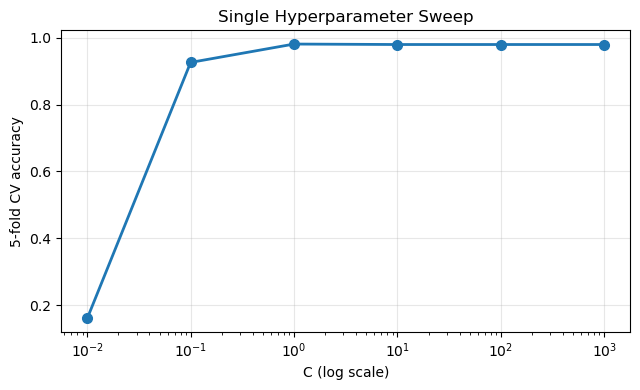

In [7]:
C_values = [0.01, 0.1, 1, 10, 100, 1000]
sweep_scores = []

for C in C_values:
    candidate = Pipeline([('scaler', StandardScaler()), ('model', SVC(C=C, random_state=42))])
    sweep_scores.append(cross_val_score(candidate, X_train, y_train, cv=cv, n_jobs=-1).mean())
    print(f'C = {C:7g}   5-fold CV accuracy = {sweep_scores[-1]:.4f}')

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.semilogx(C_values, sweep_scores, 'o-', linewidth=2, markersize=7)
ax.set_xlabel('C (log scale)'); ax.set_ylabel('5-fold CV accuracy')
ax.set_title('Single Hyperparameter Sweep'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Accuracy climbs steeply and then goes flat: anything from `C = 1` upward scores the same.
A sweep answers one question — where does this parameter stop mattering?

---
# 2. Two Hyperparameters — a Grid

`gamma` sets how far the influence of one training point reaches.
It interacts with `C`, so the two cannot be tuned one after the other: a good `C` at one `gamma` is a bad
`C` at another.

`GridSearchCV` scores every combination.
For a pipeline the parameter names are `stepname__parametername`, hence `model__C`.
Below: 4 x 4 = 16 combinations, each fitted 5 times.

In [8]:
param_grid = {'model__C': [0.1, 1, 10, 100], 'model__gamma': [1e-4, 1e-3, 1e-2, 1e-1]}

grid_two = GridSearchCV(pipeline, param_grid, cv=cv, n_jobs=-1)
grid_two.fit(X_train, y_train)

print(f'best {grid_two.best_params_}, CV {grid_two.best_score_:.4f}')

best {'model__C': 10, 'model__gamma': 0.01}, CV 0.9791


The search records everything it tried in `cv_results_`, one row per candidate.

In [9]:
results_two = pd.DataFrame(grid_two.cv_results_)

display(results_two[['param_model__C', 'param_model__gamma',
                     'mean_test_score', 'std_test_score', 'rank_test_score']].round(4))

,param_model__C,param_model__gamma,mean_test_score,std_test_score,rank_test_score
0,0.1,0.0001,0.1553,0.0446,16
1,0.1,0.0010,0.4906,0.0173,14
2,0.1,0.0100,0.9262,0.0143,12
3,0.1,0.1000,0.3458,0.0356,15
4,1.0,0.0001,0.5755,0.0072,13
5,1.0,0.0010,0.9443,0.0079,8
6,1.0,0.0100,0.9784,0.0080,3
7,1.0,0.1000,0.9311,0.0135,11
8,10.0,0.0001,0.9457,0.0068,7
9,10.0,0.0010,0.9756,0.0134,6


`best_params_` is simply the row with `rank_test_score` equal to 1.
The heatmap below is the `mean_test_score` column reshaped to 4 x 4.

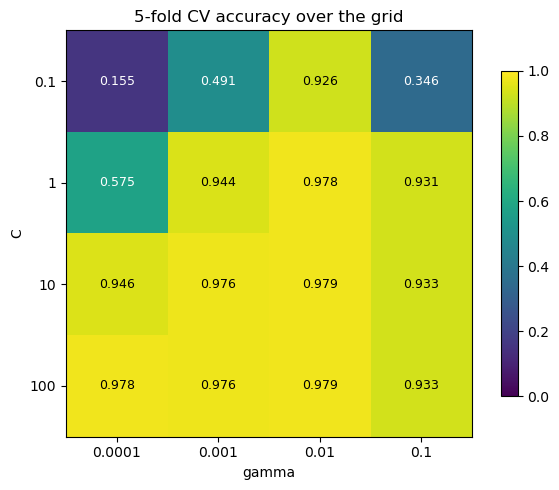

In [10]:
scores = grid_two.cv_results_['mean_test_score'].reshape(len(param_grid['model__C']),
                                                         len(param_grid['model__gamma']))

fig, ax = plt.subplots(figsize=(6.5, 5))
image = ax.imshow(scores, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(len(param_grid['model__gamma'])), [f'{g:g}' for g in param_grid['model__gamma']])
ax.set_yticks(range(len(param_grid['model__C'])), [f'{c:g}' for c in param_grid['model__C']])
ax.set_xlabel('gamma'); ax.set_ylabel('C')
ax.set_title('5-fold CV accuracy over the grid')
for i in range(scores.shape[0]):
    for j in range(scores.shape[1]):
        ax.text(j, i, f'{scores[i, j]:.3f}', ha='center', va='center', fontsize=9,
                color='white' if scores[i, j] < 0.7 else 'black')
fig.colorbar(image, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

The map is the useful output, not the single best number.
`gamma` swings accuracy from 0.16 to 0.98, while `C` only matters when `gamma` is badly chosen.

The grid's best (0.9791) is also **below the sweep's** (0.9812), which ran at the default `gamma='scale'`.
A grid only ever tries what you wrote into it.

---
# 3. The Model as Well

Two hyperparameters cost 16 candidates.
Five with five values each would cost 3125 — and the model family is not a number you can put on an axis at
all.

The three tools below search the same four families with the same budget of about 20 candidates, and each
reports its score per family before a winner.

## The Candidates

A linear model, a distance-based one, a kernel machine and a tree ensemble.

| Family | Hyperparameters searched |
|:---|:---|
| Logistic Regression | `C` |
| KNN | `n_neighbors` |
| SVC | `C`, `gamma` |
| Random Forest | `n_estimators`, `max_depth` |

---
## `GridSearchCV`

Passing a **list of dictionaries** searches several models in one call: each dictionary fixes the `model`
step and lists that family's hyperparameters.

Documentation: <https://scikit-learn.org/stable/modules/grid_search.html>

In [11]:
search_space = [
    {'model': [LogisticRegression(max_iter=2000, random_state=42)],
     'model__C': [0.1, 1, 10]},
    {'model': [KNeighborsClassifier()],
     'model__n_neighbors': [1, 3, 5, 7]},
    {'model': [SVC(random_state=42)],
     'model__C': [1, 10, 100], 'model__gamma': [1e-3, 1e-2, 1e-1]},
    {'model': [RandomForestClassifier(random_state=42)],
     'model__n_estimators': [100, 300], 'model__max_depth': [None, 10]},
]

grid_search = GridSearchCV(pipeline, search_space, cv=cv, n_jobs=-1)

start = time.time()
grid_search.fit(X_train, y_train)
grid_seconds = time.time() - start

print(f'{len(grid_search.cv_results_["params"])} candidates, {grid_seconds:.1f}s')

20 candidates, 1.2s


With a list of dictionaries the estimator itself becomes a parameter value.
`cv_results_` gains a `param_model` column holding the object, and one column per hyperparameter that is
left empty where it does not apply.

In [12]:
print('one candidate :', grid_search.cv_results_['params'][3])

one candidate : {'model': KNeighborsClassifier(), 'model__n_neighbors': 1}


The search already knows which candidate won, so there is nothing to compute.

In [13]:
grid_test = accuracy_score(y_test, grid_search.predict(X_test))
grid_winner = type(grid_search.best_params_['model']).__name__

print(f'best params : {grid_search.best_params_}')
print(f'CV / test   : {grid_search.best_score_:.4f} / {grid_test:.4f}')

best params : {'model': SVC(random_state=42), 'model__C': 10, 'model__gamma': 0.01}
CV / test   : 0.9791 / 0.9833


---
## Optuna

Nothing is listed here.
You write a function that scores **one** candidate, and Optuna calls it 20 times with values of its own
choosing.

Documentation: <https://optuna.readthedocs.io/en/stable/tutorial/10_key_features/001_first.html>

### `trial`, and What Is Ours

One call of the objective is a **trial**, and the `trial` argument is how Optuna passes values in.
`trial.suggest_float('svc_C', 1e-1, 1e3, log=True)` returns a value and records it under that name.

What is API and what is ours:

| In the code below | Where it comes from |
|:---|:---|
| `trial`, `suggest_categorical`, `suggest_float`, `suggest_int` | Optuna |
| `objective`, `family`, `'svc_C'`, `'knn_n_neighbors'` | names we picked |

`'family'` is therefore not an Optuna concept — it is a categorical parameter like any other.
The branch it selects decides which parameters are asked for next: `n_neighbors` never comes up once SVC
is chosen.

In [14]:
def objective(trial):
    family = trial.suggest_categorical(
        'family', ['LogisticRegression', 'KNeighborsClassifier', 'SVC', 'RandomForestClassifier'])

    if family == 'LogisticRegression':
        model = LogisticRegression(C=trial.suggest_float('logistic_C', 1e-2, 1e2, log=True),
                                   max_iter=2000, random_state=42)
    elif family == 'KNeighborsClassifier':
        model = KNeighborsClassifier(n_neighbors=trial.suggest_int('knn_n_neighbors', 1, 15))
    elif family == 'SVC':
        model = SVC(C=trial.suggest_float('svc_C', 1e-1, 1e3, log=True),
                    gamma=trial.suggest_float('svc_gamma', 1e-4, 1e0, log=True), random_state=42)
    else:
        model = RandomForestClassifier(n_estimators=trial.suggest_int('rf_n_estimators', 50, 400, step=50),
                                       max_depth=trial.suggest_categorical('rf_max_depth', [None, 10, 20]),
                                       random_state=42)

    candidate = Pipeline([('scaler', StandardScaler()), ('model', model)])
    return cross_val_score(candidate, X_train, y_train, cv=cv, n_jobs=-1).mean()


start = time.time()
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)
optuna_seconds = time.time() - start

print(f'{len(study.trials)} trials, {optuna_seconds:.1f}s')

20 trials, 1.5s


The suggested values come back as one flat dictionary.
Prefixed names keep the branches apart: `svc_C` and `logistic_C` are two parameters, not one.

Nothing was fitted on the full training set during the search, so the winner is rebuilt and fitted here —
`GridSearchCV` did that step for us, Optuna does not.

In [15]:
best_params = study.best_params
print(f'best params : {best_params}')

if best_params['family'] == 'LogisticRegression':
    best_model = LogisticRegression(C=best_params['logistic_C'], max_iter=2000, random_state=42)
elif best_params['family'] == 'KNeighborsClassifier':
    best_model = KNeighborsClassifier(n_neighbors=best_params['knn_n_neighbors'])
elif best_params['family'] == 'SVC':
    best_model = SVC(C=best_params['svc_C'], gamma=best_params['svc_gamma'], random_state=42)
else:
    best_model = RandomForestClassifier(n_estimators=best_params['rf_n_estimators'],
                                        max_depth=best_params['rf_max_depth'], random_state=42)

optuna_model = Pipeline([('scaler', StandardScaler()), ('model', best_model)])
optuna_model.fit(X_train, y_train)
optuna_test = accuracy_score(y_test, optuna_model.predict(X_test))

print(f'CV / test   : {study.best_value:.4f} / {optuna_test:.4f}')

best params : {'family': 'SVC', 'svc_C': 9.641958295232145, 'svc_gamma': 0.004716733098882283}
CV / test   : 0.9805 / 0.9833


### Reading the Study

The winner is one line of `study`.
The other 19 trials are still there, and they are what tells you whether the search was worth running.

In [16]:
families = ['LogisticRegression', 'KNeighborsClassifier', 'SVC', 'RandomForestClassifier']

for family in families:
    family_scores = [trial.value for trial in study.trials if trial.params['family'] == family]
    print(f'{family:24s} {len(family_scores):2d} trials   best {max(family_scores):.4f}')

LogisticRegression        4 trials   best 0.9708
KNeighborsClassifier      5 trials   best 0.9763
SVC                       9 trials   best 0.9805
RandomForestClassifier    2 trials   best 0.9743


The budget was not spread evenly: SVC got 9 trials, Random Forest 2.
Optuna kept returning to what scored well, while a grid fixes its allocation before seeing any result.

The nine SVC trials also sit on the axes of the heatmap above, so they can be drawn on the same picture.

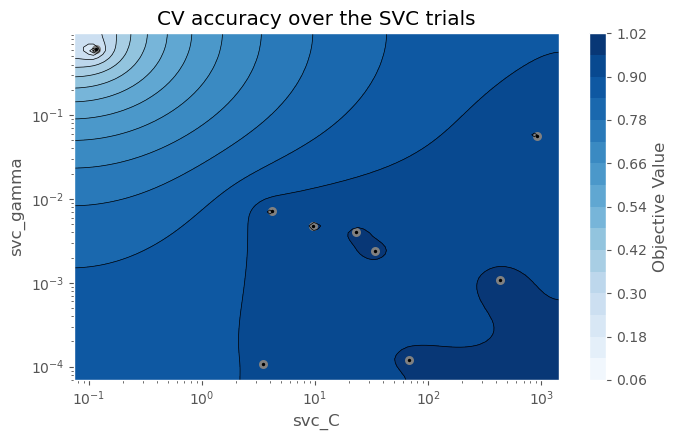

In [17]:
ax = plot_contour(study, params=['svc_C', 'svc_gamma'])
ax.set_title('CV accuracy over the SVC trials')
ax.figure.set_size_inches(7, 4.5)
plt.tight_layout(); plt.show()

Same two axes as the grid heatmap, filled in differently.
The grid put one point in every cell; Optuna clustered its points in the region that scored well and
visited the bad top-left corner once.

The surface between the points is interpolation, not measurement — read the markers, not the colours.

---
## FLAML

The families are named in `estimator_list`; their hyperparameter spaces are built in.
Nothing else is specified — no pipeline, no ranges.

`max_iter` is used instead of `time_budget` so the run does not depend on machine speed.
FLAML's `svc` is a linear SVM, so that one family is close to, but not the same as, the RBF `SVC` above.

Documentation, including the full list of built-in estimators:
<https://microsoft.github.io/FLAML/docs/Use-Cases/Task-Oriented-AutoML>

In [18]:
start = time.time()
automl_listed = AutoML()
automl_listed.fit(X_train=X_train, y_train=y_train, task='classification', metric='accuracy',
                  estimator_list=['lrl2', 'kneighbor', 'svc', 'rf'],   # FLAML's names for the four families
                  eval_method='cv', n_splits=5, max_iter=20, time_budget=-1, seed=42, verbose=0)
flaml_seconds = time.time() - start

print('best CV accuracy per family, as FLAML reports it:')
for family, loss in automl_listed.best_loss_per_estimator.items():
    print(f'  {family:12s} {1 - loss:.4f}')

best CV accuracy per family, as FLAML reports it:
  lrl2         0.9631
  kneighbor    0.9882
  svc          0.9478
  rf           0.6729


In [19]:
flaml_test = accuracy_score(y_test, automl_listed.predict(X_test))

print(f'20 candidates, {flaml_seconds:.1f}s')
print(f'best estimator : {automl_listed.best_estimator}')
print(f'best config    : {automl_listed.best_config}')
print(f'CV / test      : {1 - automl_listed.best_loss:.4f} / {flaml_test:.4f}')

20 candidates, 6.1s
best estimator : kneighbor
best config    : {'n_neighbors': 1}
CV / test      : 0.9882 / 0.9861


FLAML spends its budget unevenly, so a low number here means *the configurations that family happened to
be given scored low*.
It does not mean the family is unsuitable.

### Without `estimator_list`

The list was written to match the other two tools, not because FLAML needs it.
Left out, FLAML searches its own default catalogue of learners and reports which ones it tried.

Everything else is held fixed — same data, same `cv`, same budget of 20 iterations.

In [20]:
start = time.time()
automl_default = AutoML()
automl_default.fit(X_train=X_train, y_train=y_train, task='classification', metric='accuracy',
                   eval_method='cv', n_splits=5, max_iter=20, time_budget=-1, seed=42, verbose=0)
default_seconds = time.time() - start

print('families FLAML chose for itself:')
for family, loss in automl_default.best_loss_per_estimator.items():
    print(f'  {family:16s} {1 - loss:.4f}')

families FLAML chose for itself:
  lgbm             0.9450
  rf               0.5998
  xgboost          0.9012
  extra_tree       0.6562
  xgb_limitdepth   0.9360
  sgd              0.8866
  lrl1             0.9610


In [21]:
default_test = accuracy_score(y_test, automl_default.predict(X_test))

print(f'20 candidates, {default_seconds:.1f}s')
print(f'best estimator : {automl_default.best_estimator}')
print(f'CV / test      : {1 - automl_default.best_loss:.4f} / {default_test:.4f}')

20 candidates, 5.8s
best estimator : lrl1
CV / test      : 0.9610 / 0.9667


More families, a lower score.
Two things caused it, and neither of them is "these families are worse".

The catalogue is a different one — built around gradient boosting, with neither KNN nor SVC in it.
And `max_iter=20` is 20 configurations in total, not 20 per family: split seven ways instead of four, each
family gets about three, while FLAML starts every tree model at `n_estimators=4` and grows it only as the
budget allows.

In [22]:
start = time.time()
automl_rf_only = AutoML()
automl_rf_only.fit(X_train=X_train, y_train=y_train, task='classification', metric='accuracy',
                   estimator_list=['rf'],   # the whole budget to one family
                   eval_method='cv', n_splits=5, max_iter=20, time_budget=-1, seed=42, verbose=0)

print(f'same Random Forest, same 20 iterations, {time.time() - start:.1f}s')
print(f'  sharing with 6 others : {1 - automl_default.best_loss_per_estimator["rf"]:.4f}')
print(f'  sharing with 3 others : {1 - automl_listed.best_loss_per_estimator["rf"]:.4f}')
print(f'  alone                 : {1 - automl_rf_only.best_loss:.4f}'
      f'   grown to {automl_rf_only.best_config["n_estimators"]} trees')

same Random Forest, same 20 iterations, 4.8s
  sharing with 6 others : 0.5998
  sharing with 3 others : 0.6729
  alone                 : 0.9353   grown to 13 trees


Random Forest was never a bad model for these digits — it was a barely grown one.
That 0.60 measures the budget it received, not the family.

Naming families concentrates a small budget; it does not help FLAML search.
Leave the list out when the data is unfamiliar, and give it enough iterations for the tree models to grow.

---
## Comparison

In [23]:
summary = pd.DataFrame([
    {'tool': 'GridSearchCV', 'winner': grid_winner,                  'cv': grid_search.best_score_,    'test': grid_test,   'seconds': grid_seconds},
    {'tool': 'Optuna',       'winner': study.best_params['family'],  'cv': study.best_value,           'test': optuna_test, 'seconds': optuna_seconds},
    {'tool': 'FLAML',        'winner': automl_listed.best_estimator, 'cv': 1 - automl_listed.best_loss, 'test': flaml_test, 'seconds': flaml_seconds},
])
display(summary.round(4))

,tool,winner,cv,test,seconds
0,GridSearchCV,SVC,0.9791,0.9833,1.1778
1,Optuna,SVC,0.9805,0.9833,1.4912
2,FLAML,kneighbor,0.9882,0.9861,6.0871


- The three tools land within a few thousandths of each other, which is one or two test samples.
- That is a tie between the tools, not a ranking.
- The costs differ more than the results: the grid paid for all 20 combinations, the adaptive searches
  moved their budget to whatever was working.

---
## Summary

| | You write | It decides |
|:---|:---|:---|
| `GridSearchCV` | every candidate | nothing — it runs them all |
| Optuna | an objective function | which candidate to try next |
| FLAML | family names, or nothing | the families, the candidates and hyperparameters |

- Fix one `cv` and reuse it everywhere, or the comparisons mean nothing.
- Read the per-family scores before the winner: a low one can mean "barely tried", not "unsuitable".
- A few thousandths of CV accuracy is noise.
  Prefer the simpler model on a tie.